In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
#Reading data

import snowflake.connector

conn = snowflake.connector.connect(
    user='<USERNAME>',
    password='<PASSWORD>',
    account='<ACCOUNT_ID>', 
    warehouse='<WAREHOUSE_ID>',
    database='<DATABASE_ID>',
    schema='<SCHEMA_ID>'
)

# Define the specific table you want to stream
target_table = "<TARGET_TABLE>"

# Fetch data into a Pandas DataFrame
query = f"SELECT * FROM {target_table}"
df = pd.read_sql(query, con=conn) 
print(f"Initial load of {len(df)} rows completed.")


Initial load of 193179 rows completed.


In [4]:
df.head()

,_AIRBYTE_RAW_ID,_AIRBYTE_EXTRACTED_AT,_AIRBYTE_META,_AIRBYTE_GENERATION_ID,_ID,DATE,AMOUNT,CLAIM_ID,IS_FRAUD,CLAIM_TYPE,CUSTOMER_ID,_AB_CDC_CURSOR,_AB_CDC_DELETED_AT,_AB_CDC_UPDATED_AT
0,019f3c7e-30d0-704d-89a7-823021e81526,2026-07-07 12:11:41.848000+00:00,"{\n ""changes"": [],\n ""sync_id"": 93585978\n}",0,6a4ce7a458e2505992b2b283,2025-12-20,13277.53,CLM-1715,false,Fire,CUST-64255,178342630100019344,None,2026-07-07T11:48:51Z
1,019f3c7e-32c1-751a-84a4-bfdf06600f6c,2026-07-07 12:11:41.848000+00:00,"{\n ""changes"": [],\n ""sync_id"": 93585978\n}",0,6a4ce89e58e2505992b2c13b,2025-10-18,14313.07,CLM-1388,false,Fire,CUST-23626,178342630100023112,None,2026-07-07T11:53:01Z
2,019f3c7e-4267-733a-a0ef-fb0d234a4241,2026-07-07 12:11:41.848000+00:00,"{\n ""changes"": [],\n ""sync_id"": 93585978\n}",0,6a4ced1b58e2505992b305d9,2025-08-22,12548.35,CLM-1164,false,Accident,CUST-4830,178342630100040678,None,2026-07-07T12:12:10Z
3,019f3c7e-3095-7655-8c18-11b15177842a,2026-07-07 12:11:41.848000+00:00,"{\n ""changes"": [],\n ""sync_id"": 93585978\n}",0,6a4ce77658e2505992b2b041,2025-09-26,1578.82,CLM-7905,false,Theft,CUST-46094,178342630100018766,None,2026-07-07T11:48:06Z
4,019f3c7e-2543-79f4-988c-b927958b41da,2026-07-07 12:11:41.848000+00:00,"{\n ""changes"": [],\n ""sync_id"": 93585978\n}",0,6a4ce0a858e2505992b2792c,2026-01-20,1801.28,CLM-8680,false,Fire,CUST-64779,178342630100004676,None,2026-07-07T11:19:03Z


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 193179 entries, 0 to 193178
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   _AIRBYTE_RAW_ID         193179 non-null  str                
 1   _AIRBYTE_EXTRACTED_AT   193179 non-null  datetime64[us, UTC]
 2   _AIRBYTE_META           193179 non-null  str                
 3   _AIRBYTE_GENERATION_ID  193179 non-null  int64              
 4   _ID                     193179 non-null  str                
 5   DATE                    193179 non-null  str                
 6   AMOUNT                  193179 non-null  float64            
 7   CLAIM_ID                193179 non-null  str                
 8   IS_FRAUD                193179 non-null  str                
 9   CLAIM_TYPE              193179 non-null  str                
 10  CUSTOMER_ID             193179 non-null  str                
 11  _AB_CDC_CURSOR          193179 non-nu

In [6]:
df.columns

Index(['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META',
       '_AIRBYTE_GENERATION_ID', '_ID', 'DATE', 'AMOUNT', 'CLAIM_ID',
       'IS_FRAUD', 'CLAIM_TYPE', 'CUSTOMER_ID', '_AB_CDC_CURSOR',
       '_AB_CDC_DELETED_AT', '_AB_CDC_UPDATED_AT'],
      dtype='str')

In [7]:
df = df.drop(columns=['_AIRBYTE_RAW_ID','_AIRBYTE_META','_AIRBYTE_GENERATION_ID','_AB_CDC_CURSOR','_AB_CDC_DELETED_AT','_AB_CDC_UPDATED_AT'])
df = df.rename(columns={'_ID': 'ID'})
df = df.rename(columns={'_AIRBYTE_EXTRACTED_AT': 'EXTRACTION_TIME'})

In [8]:
df["IS_FRAUD"] = df["IS_FRAUD"].replace({'true': 1, 'false': 0, 'True': 1, 'False': 0})


In [9]:
df.head()

,EXTRACTION_TIME,ID,DATE,AMOUNT,CLAIM_ID,IS_FRAUD,CLAIM_TYPE,CUSTOMER_ID
0,2026-07-07 12:11:41.848000+00:00,6a4ce7a458e2505992b2b283,2025-12-20,13277.53,CLM-1715,0,Fire,CUST-64255
1,2026-07-07 12:11:41.848000+00:00,6a4ce89e58e2505992b2c13b,2025-10-18,14313.07,CLM-1388,0,Fire,CUST-23626
2,2026-07-07 12:11:41.848000+00:00,6a4ced1b58e2505992b305d9,2025-08-22,12548.35,CLM-1164,0,Accident,CUST-4830
3,2026-07-07 12:11:41.848000+00:00,6a4ce77658e2505992b2b041,2025-09-26,1578.82,CLM-7905,0,Theft,CUST-46094
4,2026-07-07 12:11:41.848000+00:00,6a4ce0a858e2505992b2792c,2026-01-20,1801.28,CLM-8680,0,Fire,CUST-64779


In [10]:
df["IS_FRAUD"].value_counts()

IS_FRAUD
0    162718
1     30461
Name: count, dtype: int64

In [11]:
df.isnull().sum()

EXTRACTION_TIME    0
ID                 0
DATE               0
AMOUNT             0
CLAIM_ID           0
IS_FRAUD           0
CLAIM_TYPE         0
CUSTOMER_ID        0
dtype: int64

In [12]:
df.shape[0]

193179

In [13]:
round((df["IS_FRAUD"].value_counts()[1] / df.shape[0]) * 100,2)

np.float64(15.77)

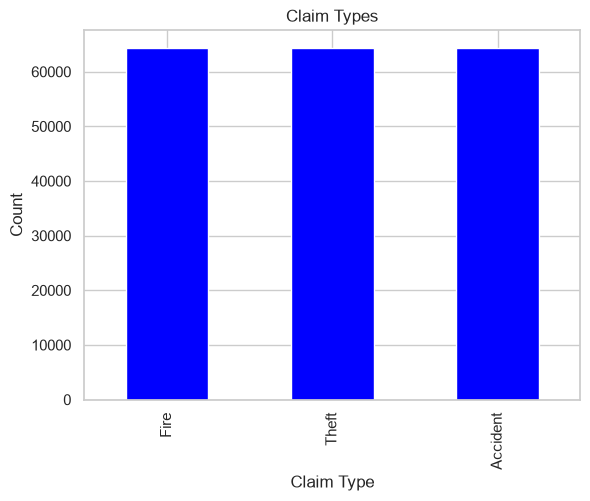

In [14]:
# Claim types
df["CLAIM_TYPE"].value_counts().plot(kind="bar", title="Claim Types",color = "blue")
plt.xlabel("Claim Type")
plt.ylabel("Count")
plt.show()

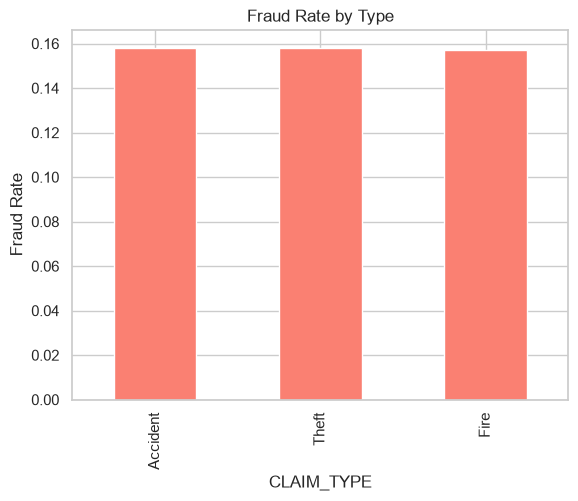

In [15]:
fraud_by_type = df.groupby("CLAIM_TYPE")["IS_FRAUD"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [16]:
df["AMOUNT"].describe().astype(int)

count    193179
mean      10053
std        5739
min         100
25%        5075
50%       10073
75%       15015
max       19999
Name: AMOUNT, dtype: int64

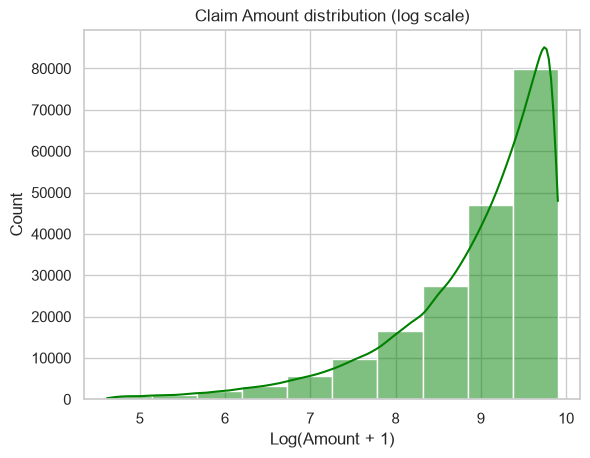

In [17]:
sns.histplot(np.log1p(df["AMOUNT"]), bins=10, kde = True, color = "green")
plt.title("Claim Amount distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

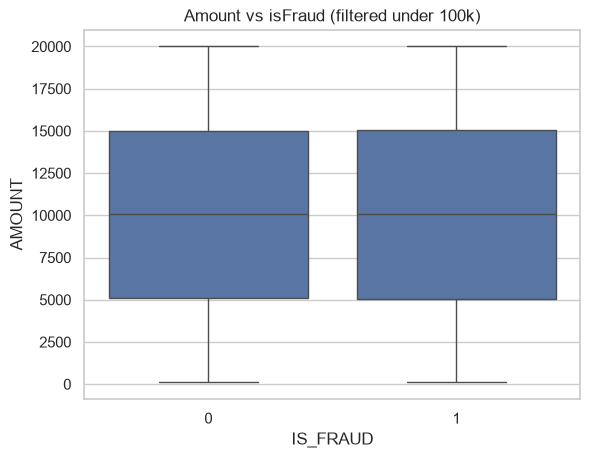

In [18]:
sns.boxplot(data=df[df["AMOUNT"] < 100000], x = "IS_FRAUD", y= "AMOUNT")
plt.title("Amount vs isFraud (filtered under 100k)")
plt.show()

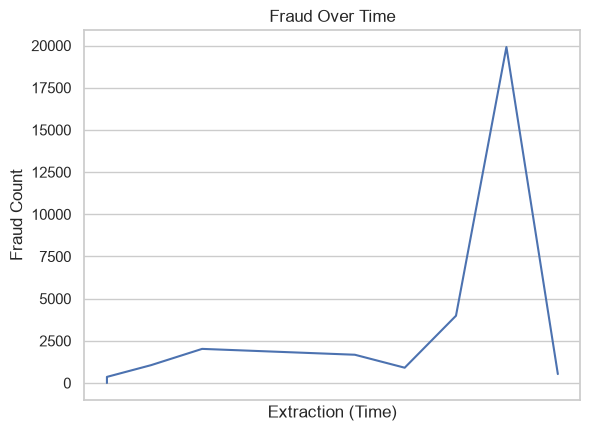

In [20]:
fraud_per_extraction = df[df["IS_FRAUD"] == 1]["EXTRACTION_TIME"].value_counts().sort_index()
plt.plot(fraud_per_extraction.index, fraud_per_extraction.values, label="Fraud per Extraction")
plt.xlabel("Extraction (Time)")
plt.ylabel("Fraud Count")
plt.title("Fraud Over Time")
plt.grid(True)
plt.xticks([]) 
plt.show()

In [21]:
df.drop(columns="EXTRACTION_TIME" , inplace=True)

In [22]:
df.head()

,ID,DATE,AMOUNT,CLAIM_ID,IS_FRAUD,CLAIM_TYPE,CUSTOMER_ID
0,6a4ce7a458e2505992b2b283,2025-12-20,13277.53,CLM-1715,0,Fire,CUST-64255
1,6a4ce89e58e2505992b2c13b,2025-10-18,14313.07,CLM-1388,0,Fire,CUST-23626
2,6a4ced1b58e2505992b305d9,2025-08-22,12548.35,CLM-1164,0,Accident,CUST-4830
3,6a4ce77658e2505992b2b041,2025-09-26,1578.82,CLM-7905,0,Theft,CUST-46094
4,6a4ce0a858e2505992b2792c,2026-01-20,1801.28,CLM-8680,0,Fire,CUST-64779


In [23]:
top_claims = df["CUSTOMER_ID"].value_counts().head(10)

In [24]:
top_claims

CUSTOMER_ID
CUST-73250    11
CUST-39063    11
CUST-6437     11
CUST-73594    11
CUST-55931    11
CUST-26622    11
CUST-27382    10
CUST-30695    10
CUST-24476    10
CUST-64855    10
Name: count, dtype: int64

In [25]:
fraudulant_cases = df[df["IS_FRAUD"]== 1]["CUSTOMER_ID"].value_counts().head(10)

In [26]:
fraudulant_cases

CUSTOMER_ID
CUST-22498    5
CUST-57433    5
CUST-14712    5
CUST-1192     5
CUST-10699    5
CUST-65802    4
CUST-20785    4
CUST-48783    4
CUST-48827    4
CUST-5540     4
Name: count, dtype: int64